# Modelling

This document follows the data cleaning and scraping by modelling the footfall data. The model is selected, tuned and fitted using the footfall data between 2019 and 2024. The model is then used later on to predict the 2025 footfall, to allow event evaluation.

The below steps are followed:

### 1) Model selection

The performance of four different machine learning models is tested using 10-fold cross validation. The models include:

* Linear regression
* Random Forest
* XGBoost
* Extra Trees Regressor

The outputs of the 10-fold cross validation process are used to calculate the error metric scores associated with that model (averaged over all folds). The MAE, the MAPE, the R2 and the RMSE metrics are compared to find the model that will best fit the data.

**Conclusion:** Random Forest Regression is the best performing model, after going through model selection.

### 2) Model Evaluation

The performance of the model is tested, using a 80-20 test split with the chronological order of the data preserved. The model performance is evaluated using the error metrics of MAE, MAPE, R2 and RMSE.

### 3) Hyperparameter Tuning


Hyperparameter tuning is performed as it allows to find the best set of hyperparameters to maximise the model's efficiency and accuracy. 

### 4) Fitting the Final Model

Using the optimal hyperparameters found during the tuning, the model is fitted again, this time using the whole dataset (no training and test splits).

### 5) Feature Importance

The feature importance of the model predictor variables is investigated.

### 6) Cross-Validated SHAP for Feature Importance

The feature importance of the model predictor variables is investigated using SHAP.

### 7) Using Model Forecast to Evaluate Events

The final model is used to quantify the change in footfall that would otherwise been predicted in 2025.

**IMPORTANT NOTE**: The '2- Footfall-Cleaning' notebook is the same between the different analysis versions tested. However, the '3- Data Scaping' and '4- Modelling' notebooks are changed to only include the locations of interest for this version of the analysis.

**Version of the analysis:** only for the polygons, and thus will only include the following locations:
* Bradford - BID
* Bradford - City Centre
* Bradford - Lister Park
* Bradford - Roberts Park
* Bradford - Local Authority

In [1]:
pip install matplotlib geopandas numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

Here the data used to do model selection, evaluate model performance and train the model before forecasting only contains the footfall data from 2019 to 2024.

In [3]:
#Load training footfall (2019-2024) data
data = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\ML Analysis - Polygons with district\footfall_cleaned_19_24.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10862 entries, 0 to 10861
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       10862 non-null  int64  
 1   datestamp                        10862 non-null  object 
 2   estimated_actual_footfall        10862 non-null  float64
 3   year                             10862 non-null  int64  
 4   month                            10862 non-null  int64  
 5   weekday                          10862 non-null  int64  
 6   week_of_year                     10862 non-null  int64  
 7   Sin_weekday                      10862 non-null  float64
 8   Cos_weekday                      10862 non-null  float64
 9   Sin_monthday                     10862 non-null  float64
 10  Cos_monthday                     10862 non-null  float64
 11  Sin_week_of_year                 10862 non-null  float64
 12  Cos_week_of_year  

In [4]:
data['area_name'].unique()

array(['Bradford - BID', 'Bradford - Local Authority',
       'Bradford - City Centre', 'Bradford - Lister Park',
       'Bradford - Roberts Park'], dtype=object)

In [5]:
data.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,year,month,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_monthday,...,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration,area_name,area_Bradford - BID,area_Bradford - City Centre,area_Bradford - Lister Park,area_Bradford - Local Authority,area_Bradford - Roberts Park
0,1,2019-01-01,54153.485,2019,1,1,1,8.660254e-01,0.5,0.201299,...,6.158333,0.0,24.490587,27067.838,Bradford - BID,1,0,0,0,0
1,2,2019-01-01,530996.000,2019,1,1,1,8.660254e-01,0.5,0.201299,...,6.024499,0.1,28.460497,27067.838,Bradford - Local Authority,0,0,0,1,0
2,4,2019-01-02,158891.385,2019,1,2,1,8.660254e-01,-0.5,0.394356,...,2.304167,0.0,10.086427,27147.844,Bradford - BID,1,0,0,0,0
3,5,2019-01-02,568621.000,2019,1,2,1,8.660254e-01,-0.5,0.394356,...,1.566167,0.0,8.496305,27147.844,Bradford - Local Authority,0,0,0,1,0
4,7,2019-01-03,56947.585,2019,1,3,1,1.224647e-16,-1.0,0.571268,...,0.387500,0.0,6.479999,27235.123,Bradford - BID,1,0,0,0,0


In [6]:
#For time series analysis, the data needs to be in chronological order
# thus there is a need to reset the indexes based on datestamp
data = data.sort_values('datestamp')
data = data.reset_index(drop=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10862 entries, 0 to 10861
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       10862 non-null  int64  
 1   datestamp                        10862 non-null  object 
 2   estimated_actual_footfall        10862 non-null  float64
 3   year                             10862 non-null  int64  
 4   month                            10862 non-null  int64  
 5   weekday                          10862 non-null  int64  
 6   week_of_year                     10862 non-null  int64  
 7   Sin_weekday                      10862 non-null  float64
 8   Cos_weekday                      10862 non-null  float64
 9   Sin_monthday                     10862 non-null  float64
 10  Cos_monthday                     10862 non-null  float64
 11  Sin_week_of_year                 10862 non-null  float64
 12  Cos_week_of_year  

In [8]:
#Drop columns that are not variables used in the analysis
data.drop(['Unnamed: 0', 'datestamp', 'year', 'month', 'weekday', 'week_of_year', 'area_name'], axis=1, inplace=True)
data.head()

,estimated_actual_footfall,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,is_weekend,...,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration,area_Bradford - BID,area_Bradford - City Centre,area_Bradford - Lister Park,area_Bradford - Local Authority,area_Bradford - Roberts Park
0,54153.485,8.660254e-01,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025,0,...,0,6.158333,0.0,24.490587,27067.838,1,0,0,0,0
1,530996.000,8.660254e-01,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025,0,...,0,6.024499,0.1,28.460497,27067.838,0,0,0,1,0
2,158891.385,8.660254e-01,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025,0,...,0,2.304167,0.0,10.086427,27147.844,1,0,0,0,0
3,568621.000,8.660254e-01,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025,0,...,0,1.566167,0.0,8.496305,27147.844,0,0,0,1,0
4,56947.585,1.224647e-16,-1.0,0.571268,0.820763,0.118273,0.992981,0.5,0.866025,0,...,0,0.387500,0.0,6.479999,27235.123,1,0,0,0,0


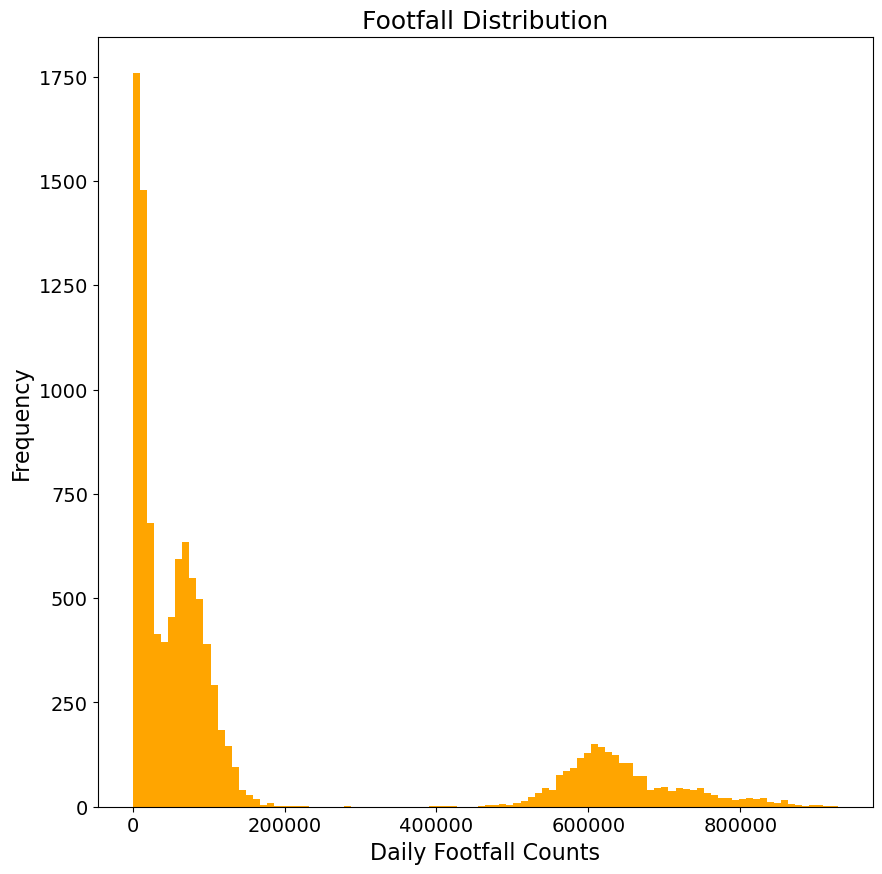

In [9]:
#Plot distribution of footfall counts
plt.figure(figsize=(10, 10))
plt.hist(data.estimated_actual_footfall, bins=100, color='orange')
plt.title('Footfall Distribution', fontsize=18)
plt.xlabel('Daily Footfall Counts', fontsize= 16)
plt.ylabel('Frequency', fontsize=16)
plt.tick_params(axis='both', labelsize= 14)
ax = plt.gca()  #get axes
ax.xaxis.get_offset_text().set_fontsize(14)
plt.show()

Explore relationship between variables.

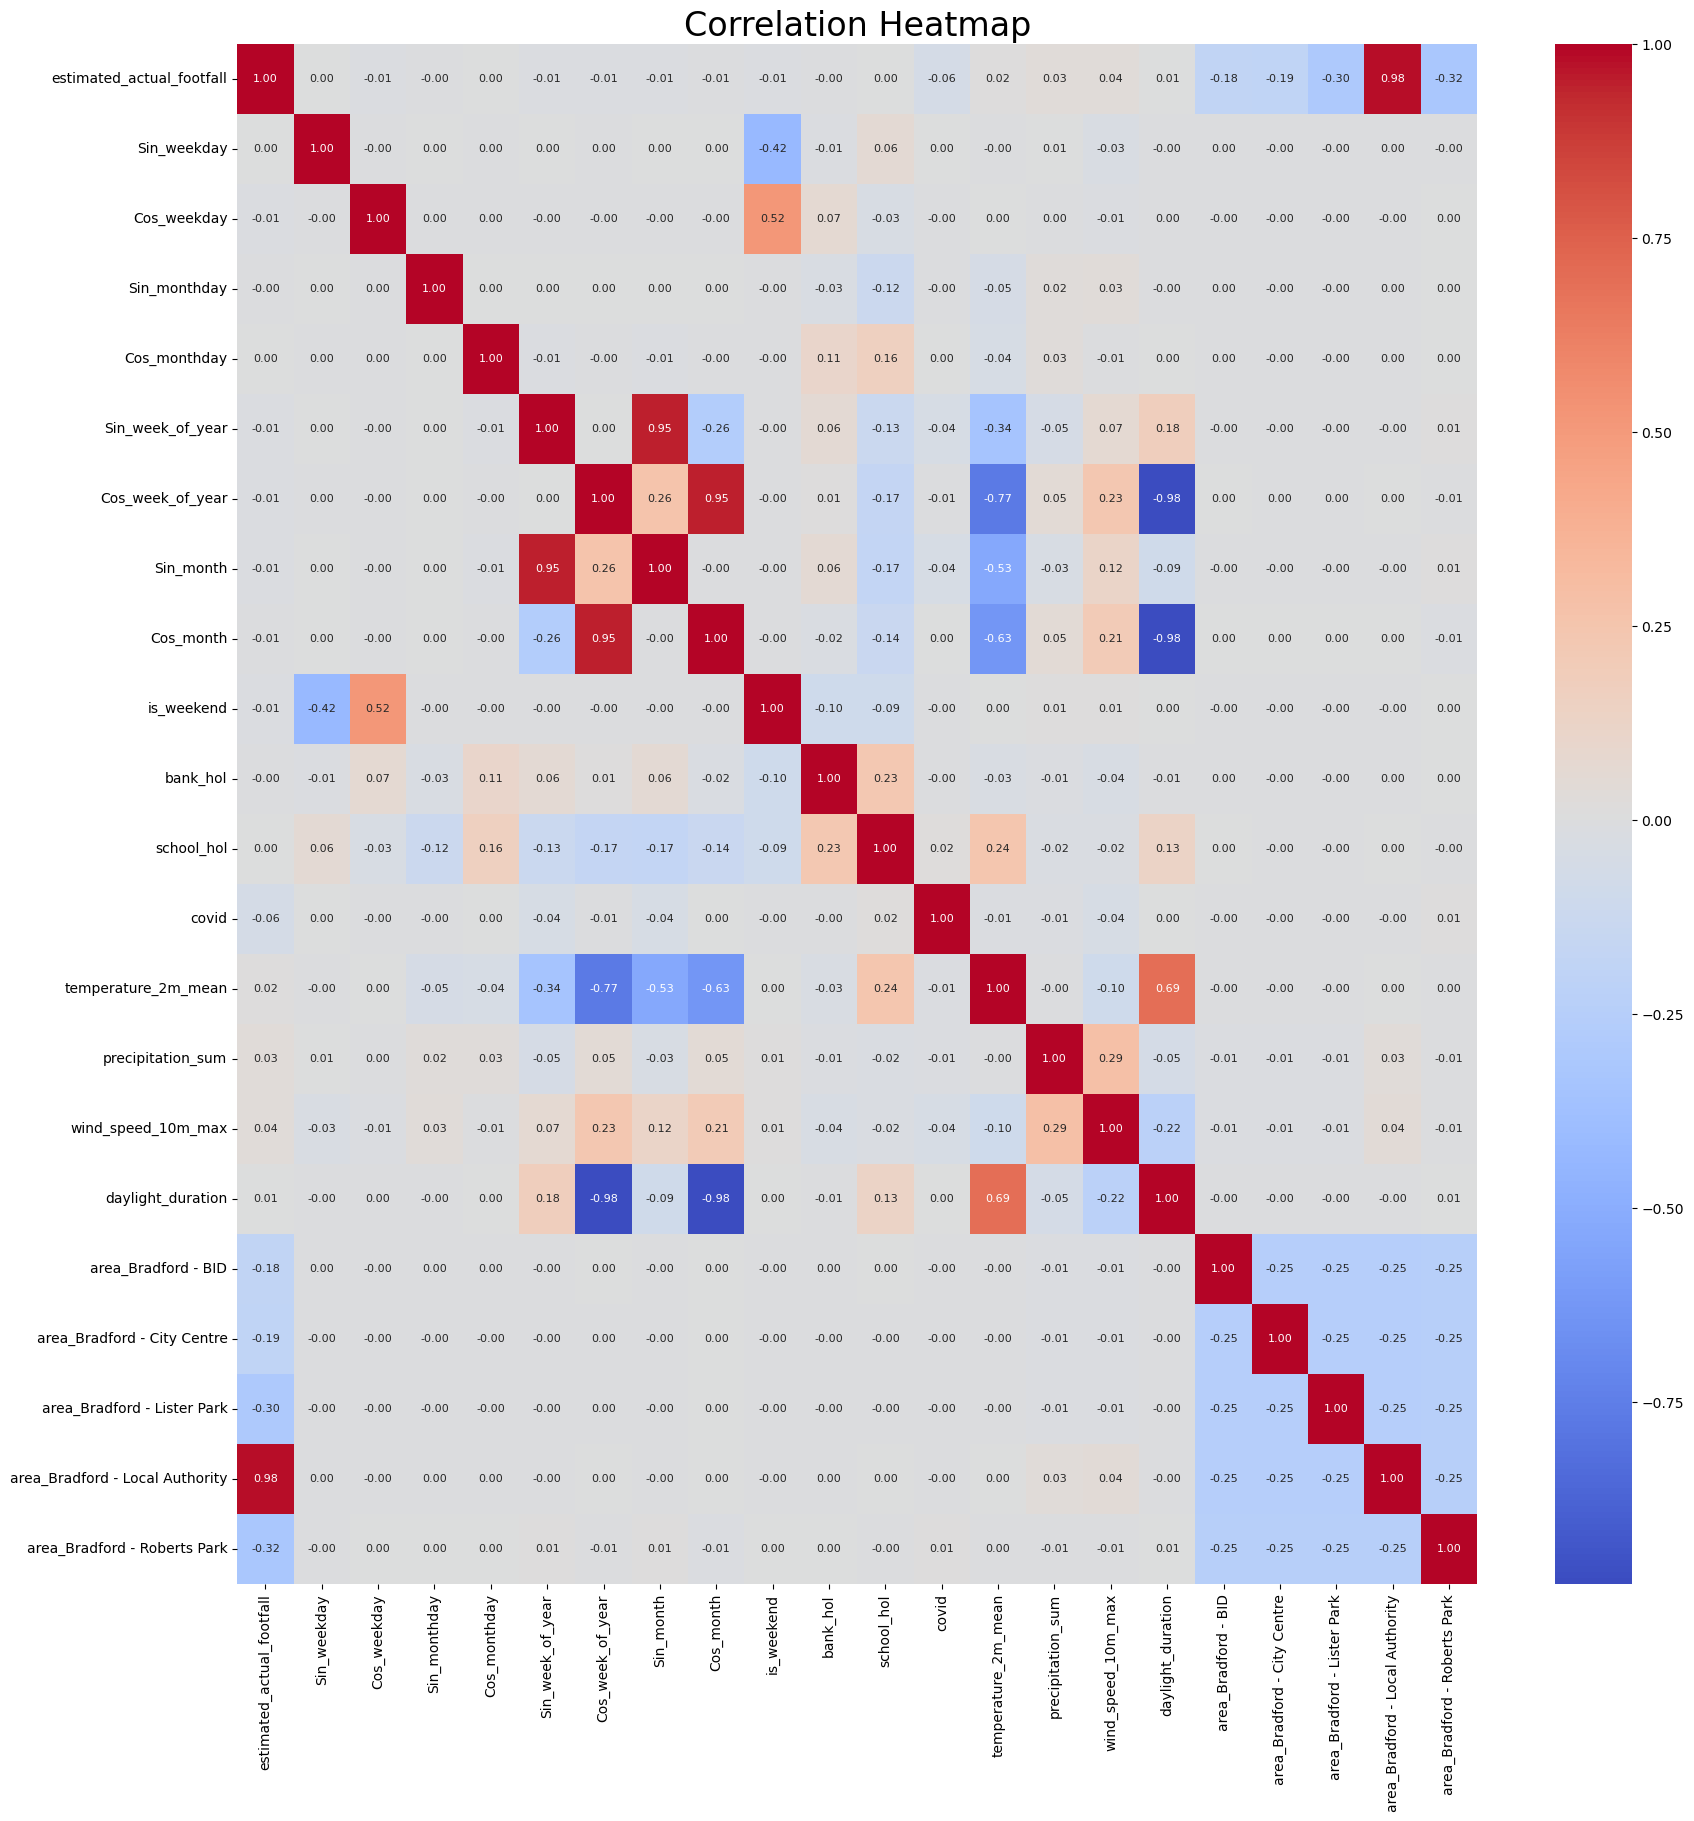

In [10]:
#Correlation Heatmap
plt.figure(figsize=(20, 20))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 8}, fmt=".2f")
plt.title('Correlation Heatmap', fontsize=24)
plt.show()

# 1- Model Selection

In [11]:
!pip install xgboost
!pip install scikit-learn==1.4.2
!pip install scikit-learn

In [12]:
#Load packages
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate
from time import time

In [13]:
#Prepare data for modelling

def prepare_x_y_data(input_data):
    data = input_data.copy()
    # Fill any missing values
    data = data.fillna(0)
    
    # Add a random variables (to compare performance of other variables against)
    #rng = np.random.RandomState(seed=42)
    #data['random'] = np.random.random(size=len(data)) #continuous random variable between 0 and 1
    #data["random_cat"] = rng.randint(3, size=data.shape[0]) #categorical random variable, integer is either 0, 1 or 2

    # Prepare data for modelling 
    # Split into predictor/predictand variables
    Xfull = data.drop(['estimated_actual_footfall'], axis =1) #Predictor variables
    Yfull = data['estimated_actual_footfall'].values #target variable

    return Xfull, Yfull

# Run function
Xfull, Yfull = prepare_x_y_data(data)

In [14]:
print("Running models with explanatory variables: ", Xfull.columns)

Running models with explanatory variables:  Index(['Sin_weekday', 'Cos_weekday', 'Sin_monthday', 'Cos_monthday',
       'Sin_week_of_year', 'Cos_week_of_year', 'Sin_month', 'Cos_month',
       'is_weekend', 'bank_hol', 'school_hol', 'covid', 'temperature_2m_mean',
       'precipitation_sum', 'wind_speed_10m_max', 'daylight_duration',
       'area_Bradford - BID', 'area_Bradford - City Centre',
       'area_Bradford - Lister Park', 'area_Bradford - Local Authority',
       'area_Bradford - Roberts Park'],
      dtype='object')


**Run the 4 models with cross-validation and TimeSeriesSplit**

The TimeSeriesSplit allows cross-validation for time series data, as future data should not be used to train a model to predict past data, random splits can cause data leakage. TimeSeriesSplit ensures that the training set always comes before the test set.

Define the error metrics for the cross-validation to return.


In [15]:
#Define error metrics
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

#Load package
from sklearn.model_selection import TimeSeriesSplit

#Split the data into 10 folds, using the TimeSeriesSplit
tscv= TimeSeriesSplit(n_splits= 10)

In [16]:
# Create dataframe to store the scores for all the models
error_metric_scores = pd.DataFrame()

In [17]:
#Create the 4 models
lr_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['linear_regressor',LinearRegression()]])
rf_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['rf_regressor', RandomForestRegressor(random_state = 1, n_jobs = 10)]])
xgb_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['xgb_regressor',xgb.XGBRegressor(random_state=1, n_jobs = 16)]])
et_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['et_regressor',ExtraTreesRegressor (random_state = 1, n_jobs = 16)]])

#Create dictionary to contain model results
models_dict = {"linear_regressor": lr_model_pipeline, 
               "xgb_regressor":xgb_model_pipeline,
               "rf_regressor":rf_model_pipeline,
               "et_regressor": et_model_pipeline}

In [18]:
# Run models with 10 fold time series split cross validation

for model_name, model_pipeline in models_dict.items():
    print(model_name)
    # Use cross_validate to return the error scores associated with this model and this data
    start = time()
    model_output = cross_validate(model_pipeline, Xfull, Yfull, cv= tscv, scoring=error_metrics, error_score="raise")

    end = time()
    print('Ran in {} minutes'.format(round((end - start)/60),2)) #how long model took to run
    
    # Formulate the different error scores into a dataframe
    error_metrics_df =pd.DataFrame({'mae': round(abs(model_output['test_neg_mean_absolute_error'].mean()),2), 
                  'mape': round(abs(model_output['test_neg_mean_absolute_percentage_error'].mean()),2),
                  'r2': round(abs(model_output['test_r2'].mean()),2), 
                  'rmse': round(abs(model_output['test_neg_root_mean_squared_error'].mean()),2)},
                 index =[model_name])
        
    # Add evaluation metric scores for this model to the dataframe containing the metrics for each model
    error_metric_scores = pd.concat([error_metric_scores, error_metrics_df])

linear_regressor
Ran in 0 minutes
xgb_regressor
Ran in 0 minutes
rf_regressor
Ran in 0 minutes
et_regressor
Ran in 0 minutes


In [19]:
#Check results
error_metric_scores.head()

,mae,mape,r2,rmse
linear_regressor,4.160586e+14,2.889356e+10,4.587116e+19,4.772901e+14
xgb_regressor,2.948200e+04,6.600000e-01,9.600000e-01,4.671842e+04
rf_regressor,2.811711e+04,5.800000e-01,9.600000e-01,4.489513e+04
et_regressor,2.846368e+04,5.700000e-01,9.600000e-01,4.556879e+04


**Results**:
* Mean Absolute Error: Random Forest has the best accuracy (lowest mae)
* Mean Absolute Percentage Error: Extra Trees Regressor has the best accuracy (lowest mape)
* R-Squared: Several models have the best accuracy (highest r2)
* Root Mean Squared Error: Random Forest has the best accuracy (lowest rmse)

Conclusion: Random Forest is the best performing model. It slightly outperforms XGBoost and Extra Trees Regressor.

**Note**: It also outperforms the SARIMA model built in a different trial notebook.

# 2- Evaluating the Random Forest Regression model

The first 80% of the data is used for training, and the last 20% for testing. Potential issues: the final portion of time might exhibit different patterns to the rest of the time.

As we are analysing time series data, we cannot choose random samples and assign them to either the test set or the train set because it doesn't make sense to use values from the future to forecast the past. There is a temporal dependency between observations, and this must be preserved during testing.

So, need to ensure that the test set always has a later time stamp than the training set.

In [20]:
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

In [21]:
# Custom function for neg_mean_absolute_percentage_error
def neg_mean_absolute_percentage_error(y_true, y_pred):
    return -100 * np.mean(np.abs((y_true - y_pred) / y_true))

In [22]:
# Define the error metrics for the cross-validation to return
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

In [23]:
# Set up model pipeline
rf_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['rf_regressor', RandomForestRegressor(random_state = 1, n_jobs = 10)]])
model_dict = {"rf_regressor":rf_model_pipeline}

Get testing and training data

In [24]:
Xfull, Yfull = prepare_x_y_data(data)
dates = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\ML Analysis - Polygons with district\footfall_cleaned_19_24.csv")['datestamp']

In [25]:
# Create train/test index lists based on a 80/20 split of data by chronological order
train_index = Xfull[0:int(len(Xfull)*0.8)].index.tolist()
test_index = Xfull[int(len(Xfull)*0.8):].index.tolist()

In [26]:
# Lists to store the error metric scores
mae_scores = []
rmse_scores= []
r2_scores= []
neg_mae_scores = []
# Lists to store predicted and actual values
predicted_values=[]
observed_values = []
# List to store the dates
dates_used = []

In [27]:
start = time()

# Get train and testing data for this fold
print(f"train index: {len(train_index)}")
print(f"test index: {len(test_index)}")
print(f"percentage of data used as testing: {round(len(test_index)/len(train_index)*100,1)}")

X_train, X_test = Xfull.iloc[train_index], Xfull.iloc[test_index]
y_train, y_test = Yfull[train_index], Yfull[test_index]

# Fit the model on the training data
rf_model_pipeline.fit(X_train, y_train)
# Use it to make predictions on the testing data, and store these
y_pred = rf_model_pipeline.predict(X_test)
predicted_values.append(y_pred)
# Store the datetimes
dates_used.append(dates[train_index])
# Store the actual values for the testing data
observed_values.append(y_test)
# Calculate the error metrics for this fold and append to the scores lists
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
rmse_scores.append(root_mean_squared_error(y_test, y_pred))
neg_mae_scores = [-score for score in mae_scores]        

end = time()
#Get time it took to run model in full
print('Ran cross_val_predict in {} minutes'.format(round((end - start)/60),2))

train index: 8689
test index: 2173
percentage of data used as testing: 25.0
Ran cross_val_predict in 0 minutes


In [28]:
# Store lists of predicted and observed values
predicted_values_all = []
observed_values_all= []
for i in range(len(predicted_values)):
    for j in range(len(predicted_values[i])):
        observed_values_all.append(observed_values[i][j])
        predicted_values_all.append(predicted_values[i][j])

In [29]:
# Print evaluation metrics
print(f"Mean absolute error: {mae_scores}")
print(f"Mean R2: {r2_scores}")
print(f"Mean RMSE: {rmse_scores}")

Mean absolute error: [np.float64(28878.849198044176)]
Mean R2: [np.float64(0.9625389345057666)]
Mean RMSE: [np.float64(45356.61672216324)]


**Results:**
The Mean Absolute Error and Mean RMSE are quite good. The Mean R-Squared is high, indicating the model is good at explaining footfall variability.

There is a need to tune the model's hyperparameters to improve the scores.

# 3- Hyperparameters Tuning with RandomizedSearchCV
Hyperparameter tuning allows to find the best set of hyperparameters to maximise the model's efficiency and accuracy. The Randomized Search exhaustively searches through all possible combinations of parameters provided in the param_grid.

The TimeSeriesSplit allows cross-validation for time series data, as future data should not be used to predict past data and random splits can cause data leakage. TimeSeriesSplit ensures that the training set comes before the test set.

As the model fitting is manually done here, the X values need to be scaled manually, whereas they were previously within the model pipeline.

In [30]:
# Define the error metrics for the cross-validation to return
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

In [31]:
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state= 1))])

In [32]:
#Create HyperParameter grid
param_grid = {
    'rf__n_estimators': [50, 100, 150, 200, 250, 300], #number of trees
    'rf__max_depth': [10, 20, 30, 40, None], #maximum depth of each tree
    'rf__min_samples_split': [2, 5, 10], #minimum n° of samples required to split a node
    'rf__min_samples_leaf': [1, 2, 4], #minimum samples at leaf node
    'rf__max_features': ['sqrt', 'log2', None], #n° of features to consider per split
    'rf__bootstrap': [True, False]
}

**Warning:** the following code takes 55 minutes to run. Here TimeSeriesSplit only has 5 splits as it is computationally expensive and would take a lot more time to do 10 splits.

In [33]:
#Find the best hyperparameters settings for this model
#from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

#TimeSeriesSplit CV
#tscv= TimeSeriesSplit(n_splits= 5)

#rfr_Rsearch = RandomizedSearchCV(estimator= rf_model, 
                            #param_distributions=param_grid, 
                            #cv= tscv, 
                            #verbose=2, 
                            #n_iter=100, 
                            #random_state=1,
                            #n_jobs= 1,
                            #scoring= 'neg_mean_absolute_error',
                            #return_train_score= True
                            #)
#rfr_Rsearch.fit(X_train, y_train)

#Display best hyperparameters
#print('Best hyperparameters:', rfr_Rsearch.best_params_)
#print('Best score', -rfr_Rsearch.best_score_)

Results: Best hyperparameters: {'rf__n_estimators': 300, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': None, 'rf__bootstrap': True}
Best score 26929.208410994917

In [34]:
#Evaluate the holdout test set
#Make predictions
#y_pred = rfr_Rsearch.best_estimator_.predict(X_test)

#Use predictions to evaluate model
#mae = mean_absolute_error(y_test, y_pred)
#r2 = r2_score(y_test, y_pred)
#rmse = root_mean_squared_error(y_test, y_pred)
#mape = mean_absolute_percentage_error(y_test, y_pred)

# Print evaluation metrics
#print(f"MAE: {mae}")
#print(f"R2: {r2}")
#print(f"RMSE: {rmse}")
#print(f"MAPE: {mape}")

Results:
* MAE: 26870.91497406585
* R2: 0.9693325425029077
* RMSE: 41038.31068286163
* MAPE: 0.5242088841044745

## Plot predicted vs actual values

In [35]:
pip install datashader

Note: you may need to restart the kernel to use updated packages.


In [36]:
import datashader as ds
from datashader.mpl_ext import dsshow

# Code from: https://stackoverflow.com/questions/20105364/how-can-i-make-a-scatter-plot-colored-by-density-in-matplotlib/53865762#53865762
def using_datashader(ax, x, y, normalisation):
    df = pd.DataFrame(dict(x=x, y=y))
    dsartist = dsshow(df,ds.Point("x", "y"),ds.count(), vmin=0.1, vmax=100,norm=normalisation,aspect="auto",ax=ax)
    cbar = plt.colorbar(dsartist, ax=ax)
    cbar.ax.tick_params(labelsize=10) 

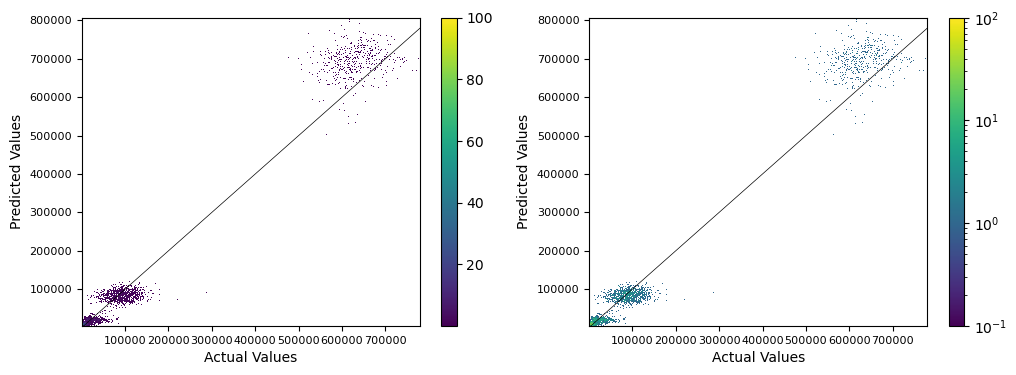

In [37]:
#Plot log and linear scales

import datashader as ds
from datashader.mpl_ext import dsshow
fig, axs = plt.subplots(ncols=2, figsize = (12,4))

# Plot with linear scale
using_datashader(axs[0], y_test, predicted_values_all, 'linear')
axs[0].plot([Yfull.min(), Yfull.max()], [Yfull.min(), Yfull.max()], c='k', lw=0.5)
axs[0].set_ylabel("Predicted Values", size=10)
axs[0].set_xlabel("Actual Values", size=10)
# axs[0].set_xlim([0, 2000])
# axs[0].set_ylim([0, 2000])
axs[0].tick_params(axis='both', which='major', labelsize=8)

# Plot with log scale
using_datashader(axs[1], y_test, predicted_values_all, 'log')
axs[1].plot([Yfull.min(), Yfull.max()], [Yfull.min(), Yfull.max()], c='k', lw=0.5)
axs[1].set_ylabel("Predicted Values", size=10)
axs[1].set_xlabel("Actual Values", size=10)
# axs[1].set_xlim([0, 2000])
# axs[1].set_ylim([0, 2000]);
axs[1].tick_params(axis='both', which='major', labelsize=8)

# 4- Fitting Final RFR Model

In [38]:
#Prepare data
Xfull, Yfull = prepare_x_y_data(data)

The final model is fitted, using all of the data (no train or test sets) and the optimal hyperparameters found with tuning.

In [39]:
# Fit the final model
rfr_pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators= 300,
                                  max_depth= None,
                                  min_samples_split= 2,
                                  min_samples_leaf = 2,
                                  max_features= 'sqrt',
                                  random_state= 1,
                                  bootstrap= True))])

#Run the Random Forest Regressor, with the whole dataset
rfr_pipeline_final.fit(Xfull, Yfull)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_features='sqrt', min_samples_leaf=2,
                                       n_estimators=300, random_state=1))])

# 5- RFR Model Feature Importance

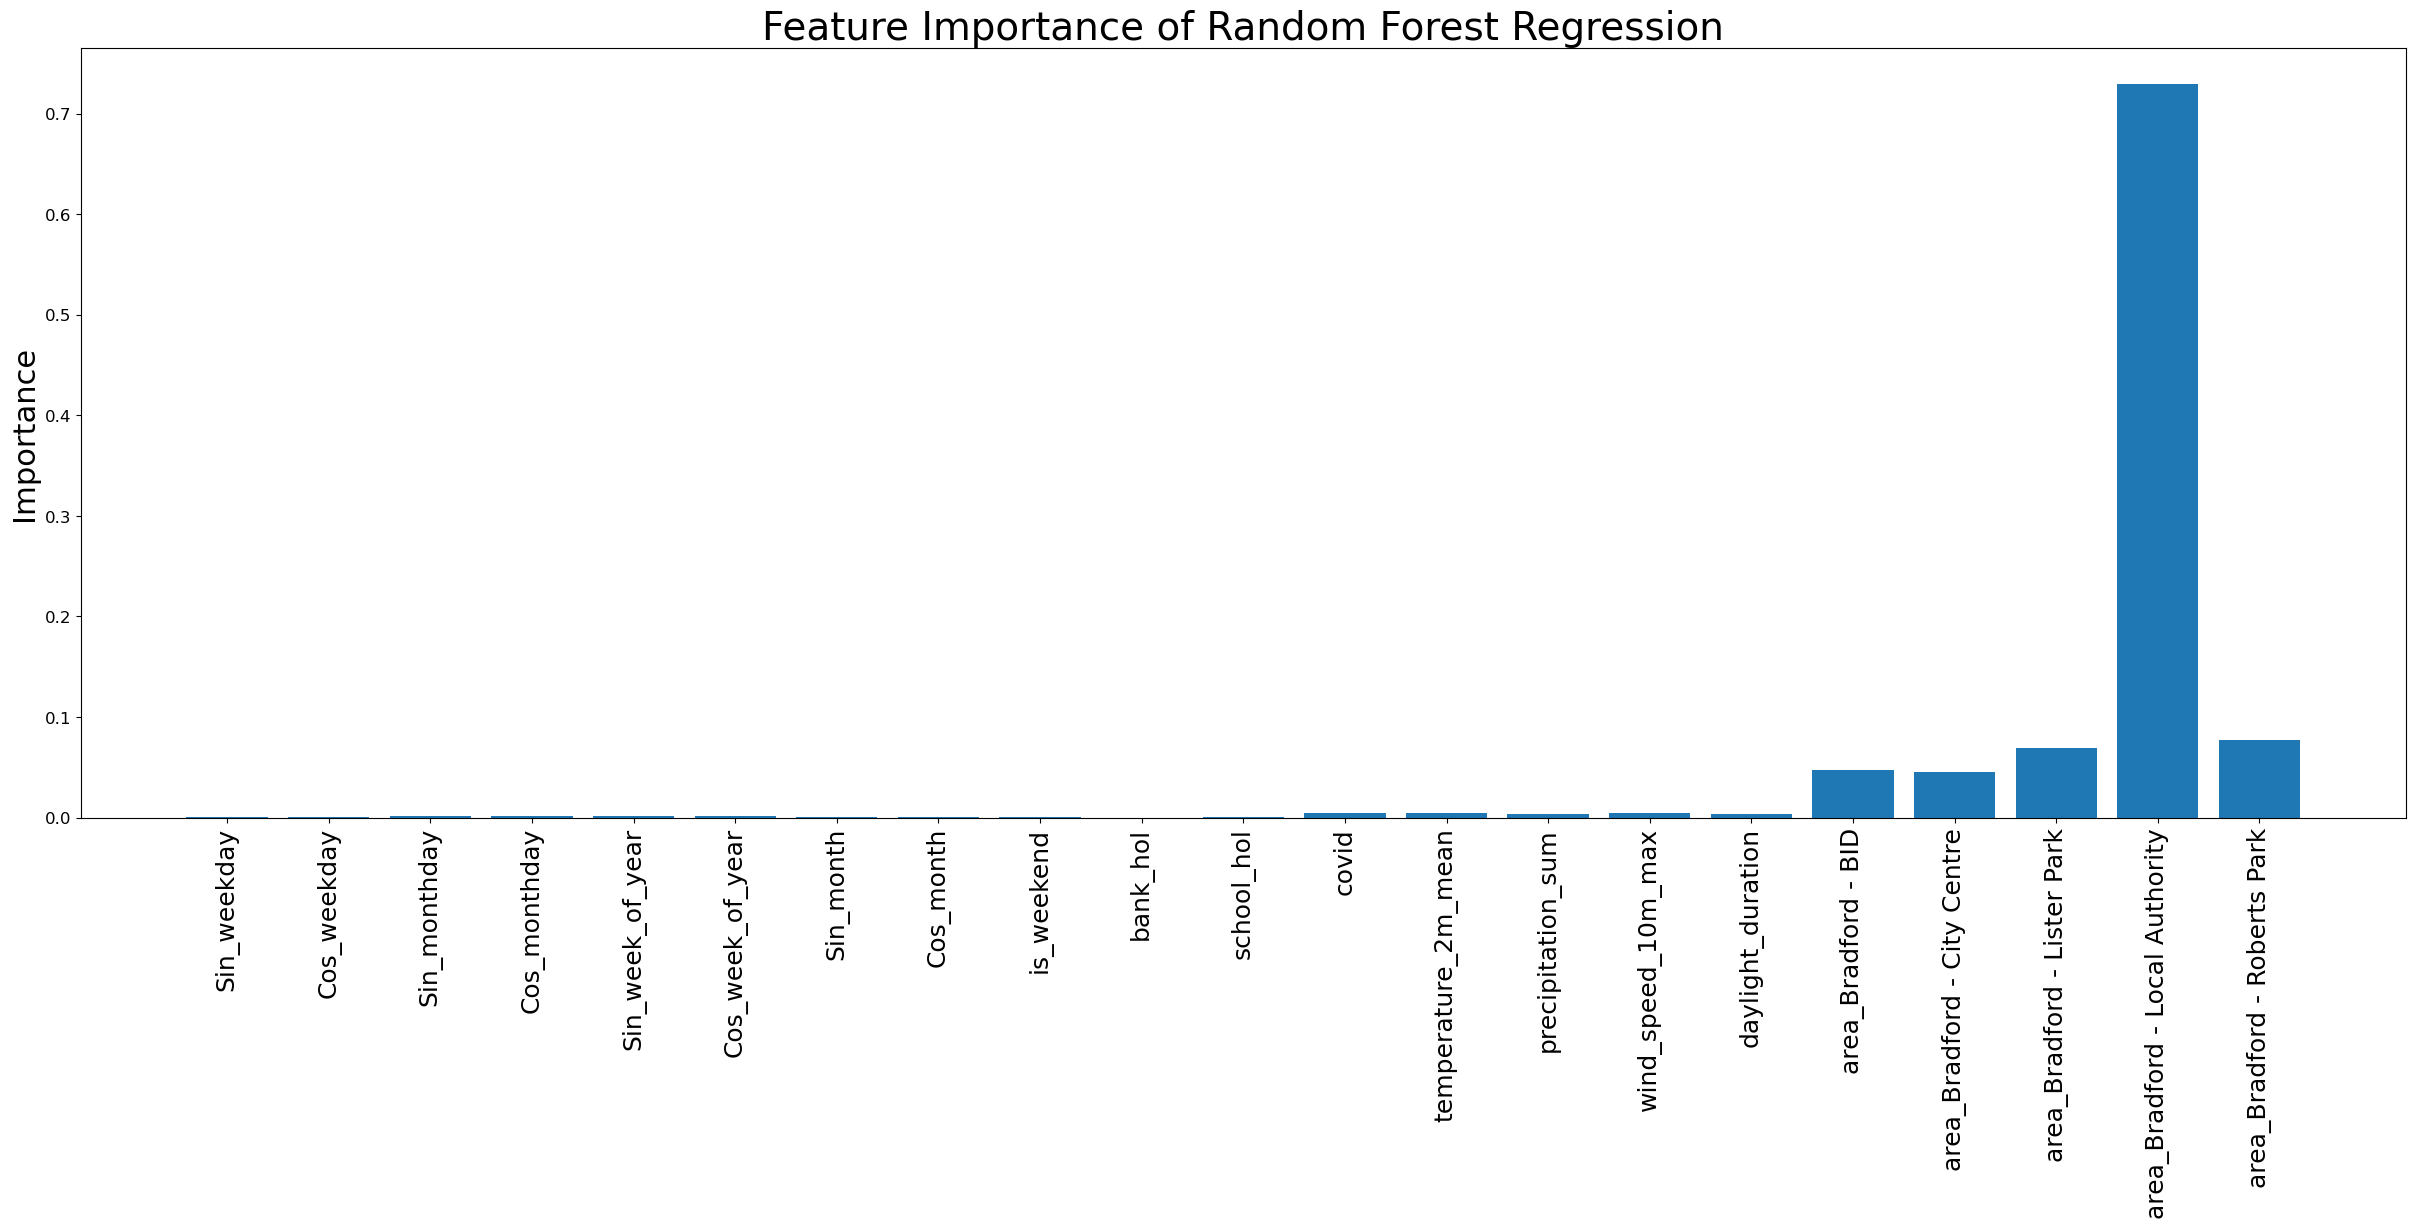

In [40]:
#Extract the rfr model from inside the pipeline
rf_model_final = rfr_pipeline_final.named_steps['rf']
#Extract feature importance from model
importance = rf_model_final.feature_importances_
#Extract feature names
features = Xfull.columns.tolist()

#Plot
plt.figure(figsize=(30, 10))
plt.bar(features, importance)
plt.title('Feature Importance of Random Forest Regression', fontsize= 28)
plt.ylabel('Importance', fontsize= 22)
plt.xticks(rotation=90, fontsize=18)
plt.yticks(size=12)
plt.show()

In [41]:
#Check feature importance values of model
for feat, imp in zip(Xfull.columns, importance):
    print(f"{feat}: {imp:.4f}")

Sin_weekday: 0.0007
Cos_weekday: 0.0009
Sin_monthday: 0.0021
Cos_monthday: 0.0018
Sin_week_of_year: 0.0018
Cos_week_of_year: 0.0017
Sin_month: 0.0009
Cos_month: 0.0008
is_weekend: 0.0006
bank_hol: 0.0001
school_hol: 0.0003
covid: 0.0044
temperature_2m_mean: 0.0043
precipitation_sum: 0.0037
wind_speed_10m_max: 0.0050
daylight_duration: 0.0032
area_Bradford - BID: 0.0469
area_Bradford - City Centre: 0.0456
area_Bradford - Lister Park: 0.0693
area_Bradford - Local Authority: 0.7291
area_Bradford - Roberts Park: 0.0769


# 6- Cross-Validated SHAP for Feature Importance Analysis

The SHapley Additive exPlanation (SHAP) method is used to investigate RFR model feature importance.

Cross-validation allows generalization of the model. Results from a simple train/test split are liable to drastic changes based on how the data is partitioned. Timeseries cross-validation is prefered to account for the chronological order of the data. I split the data into 5 folds, and separate each fold into training (fold[0]) and test data (fold[1]).

In [42]:
#Prepare data
Xfull, Yfull = prepare_x_y_data(data)

#Ensure index is time-ordered
Xfull = Xfull.sort_index()
Yfull = pd.Series(Yfull, index= Xfull.index)

In [43]:
#TimeSeriesSplit Cross-Validation
from sklearn.model_selection import TimeSeriesSplit
tscv= TimeSeriesSplit(n_splits= 5)

In [44]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [45]:
#Load SHAP package
import shap
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

In [46]:
#5-Fold TimeSeries Cross-Validation Loop

#Create empty lists
SHAP_values_per_fold = [] #store shap values

R2_scores = []
mse_scores = []
mae_scores = []
Y_test_all = []
Y_pred_all = []

#Loop though each fold (i)
for fold, (train_idx, test_idx) in enumerate(tscv.split(Xfull), 1):
    #Print fold number (check)
    print(f'Fold Number: {fold}')

    #Split data according to indices into training and test sets
    X_train, X_test = Xfull.iloc[train_idx], Xfull.iloc[test_idx]
    Y_train, Y_test = Yfull.iloc[train_idx], Yfull.iloc[test_idx]

    #Train Random Forest Regression model
    rfr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators= 300,
                                  max_depth= None,
                                  min_samples_split= 2,
                                  min_samples_leaf = 2,
                                  max_features= 'sqrt',
                                  random_state= 1,
                                  bootstrap= True))])
    
    #Fit pipeline
    rfr_pipeline.fit(X_train , Y_train)
    
    #Predict Y using pipeline
    Y_pred = rfr_pipeline.predict(X_test)
    
    #Save the evaluation metrics for each fold and add to list
    R2_scores.append(r2_score(Y_test, Y_pred))
    mse_scores.append(mean_squared_error(Y_test, Y_pred))
    mae_scores.append(mean_absolute_error(Y_test, Y_pred))
    
    #Save the predictions and test values
    Y_test_all.append(Y_test)
    Y_pred_all.append(pd.Series(Y_pred, index= Y_test.index))


    #Extract the trained RF model from the pipeline
    rf_model = rfr_pipeline.named_steps['rf']
    #Scale the test data (because have previously scaled the training data)
    X_test_scaled = rfr_pipeline.named_steps['scaler'].transform(X_test)


    #SHAP values calculation
    #Create Tree Explainer object that can calculate shap values from model
    explainer = shap.TreeExplainer(rf_model)
    #Calculate SHAP values for test dataset of current fold
    shap_values_fold = explainer.shap_values(X_test_scaled)
    #Store SHAP values with their original X indices to ensure alignement
    shap_df_fold = pd.DataFrame(shap_values_fold,
                                columns=Xfull.columns,
                                index= X_test.index)
    #Append each fold 
    SHAP_values_per_fold.append(shap_df_fold)

Fold Number: 1
Fold Number: 2
Fold Number: 3
Fold Number: 4
Fold Number: 5


In [47]:
#Concatenate all shap values and reorder indices to match original X order
shap_df = pd.concat(SHAP_values_per_fold).sort_index()

#Create dataframes with outputs
results_df = pd.DataFrame({
    'Y_test': Y_test_all,
    'Y_pred': Y_pred_all
}).sort_index()

#Metrics per fold (for all 10 folds)
metrics_df = pd.DataFrame({
    'Fold': list(range(len(R2_scores))),
    'R2': R2_scores,
    'MSE': mse_scores,
    'MAE': mae_scores
})

In [48]:
#Check
shap_df

#Note: The TimeSeries takes the first 1812 rows for training sets
# thus their SHAP values aren't computed
# this is normal for time-series cross-validation

,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,is_weekend,bank_hol,...,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration,area_Bradford - BID,area_Bradford - City Centre,area_Bradford - Lister Park,area_Bradford - Local Authority,area_Bradford - Roberts Park
1812,-297.789070,2921.488240,-9.231157,1185.480153,-1372.783275,-2360.332691,-2306.586874,-2493.119703,397.933120,-2.691949,...,0.000000,-3041.627436,1177.601731,765.113174,-1445.805994,6259.126555,-25472.479019,17875.303316,-93666.475800,20193.484943
1813,-183.683755,1431.372624,681.008706,1794.531403,-1199.083930,954.399629,-2328.743460,-1868.634188,670.228770,-61.415588,...,0.000000,-2623.857121,749.823027,1665.935689,-1431.267305,2539.749158,2087.129466,-65764.073031,-93076.097019,15656.154622
1814,235.512323,2432.497499,-1611.648706,5699.400836,-10300.842370,-17671.492401,-12403.643483,-7009.813773,1283.852060,0.010480,...,0.000000,-8404.383281,2031.434361,1477.521246,-12874.579198,26845.909603,25451.954672,39127.545963,304552.040422,41838.057773
1815,-210.863848,1065.314281,291.374297,1628.873046,-1452.354257,-1584.934545,-2169.502536,-1468.096272,408.298618,-19.947455,...,0.000000,-3190.124222,1169.359885,1408.680545,-2098.095465,2064.114037,2207.582782,13045.496443,-91041.923652,-78579.259478
1816,-1699.061727,429.573015,-2922.549035,4113.550749,-11933.197327,-20385.219424,-13856.949944,-8928.262750,1443.920150,15.668410,...,0.000000,-9052.532282,-139.696621,1930.937805,-14234.612571,27179.761004,24701.442737,39591.386220,304663.587021,42172.041444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10857,348.337499,-48.193880,7.598728,2042.925236,-677.966971,-2266.917983,-198.112160,-697.238324,789.432949,-44.861208,...,5836.689481,-742.818132,2218.551970,-812.296499,-929.417568,1367.266793,3907.232835,-68650.816310,-100452.683619,14789.399121
10858,690.707992,-396.434110,-408.937882,2171.005603,-2617.813202,-9300.510574,-1359.945561,-2695.100523,2034.502569,77.365460,...,15747.971395,-1222.138363,2032.675769,-135.065213,-7518.165285,27053.087615,31591.543334,41211.609791,330349.460152,42982.201869
10859,804.563939,118.716968,-144.503040,1897.523304,-1721.457599,-3946.287306,-151.445921,-590.862106,1349.647023,51.066918,...,8653.333110,-406.042490,3430.439901,45.283006,-1857.921751,-29048.606491,7753.575163,17160.794006,-104084.145782,19378.640038
10860,968.853998,445.049616,-290.105254,2011.159261,-519.718701,-2689.893870,284.740513,-897.063707,751.947305,-53.494609,...,7543.879132,-68.017904,1818.099879,264.356900,-2082.797194,5265.716482,-31966.457091,17213.717431,-100388.532605,18992.252444


In [49]:
#Get average metrics over the 5 folds
mae = metrics_df['MAE'].mean()
mse = metrics_df['MSE'].mean()
r2 = metrics_df['R2'].mean()

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Absolute Error: 28110.399071145162
Mean Squared Error: 2123004654.7209022
R² Score: 0.9651185493569077


Text(676.2548611111112, 0.5, 'Feature Value')

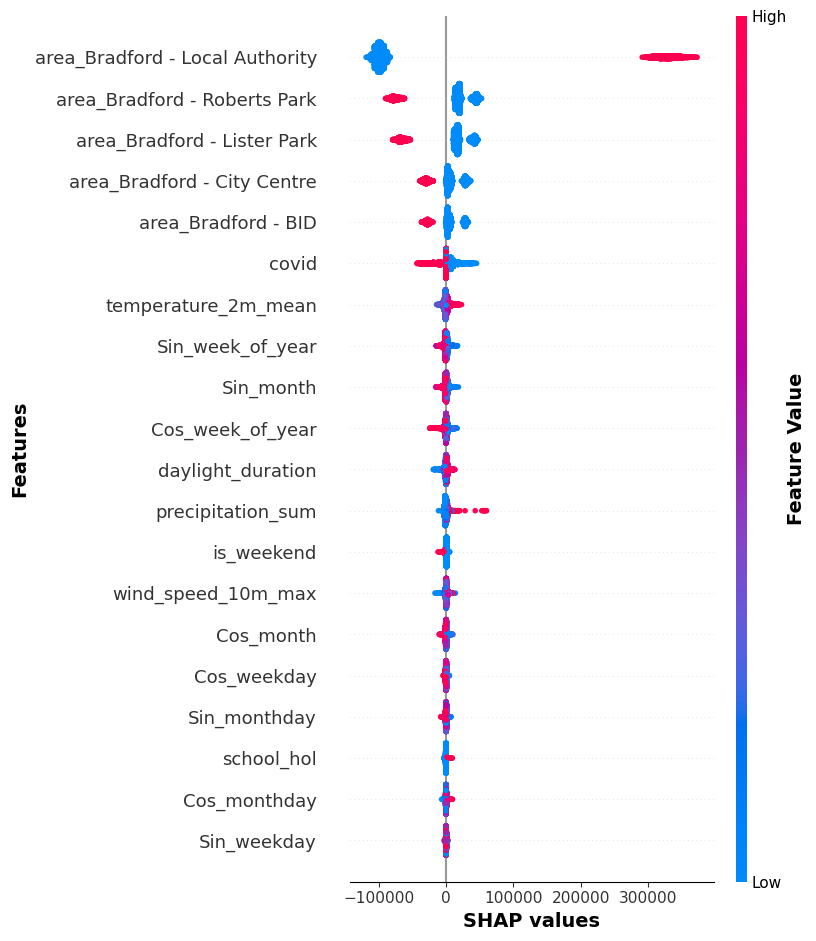

In [50]:
#Plot summary SHAP values
plt.figure(figsize=(40, 10))
shap.summary_plot(shap_df.values, 
                  Xfull.loc[shap_df.index], 
                  show = False)
plt.title('')
plt.xlabel('SHAP values', fontsize=14, weight='bold')
plt.ylabel('Features', fontsize=14, weight='bold')
cbar = plt.gcf().axes[-1] 
cbar.set_ylabel('Feature Value', fontsize=14, weight='bold')

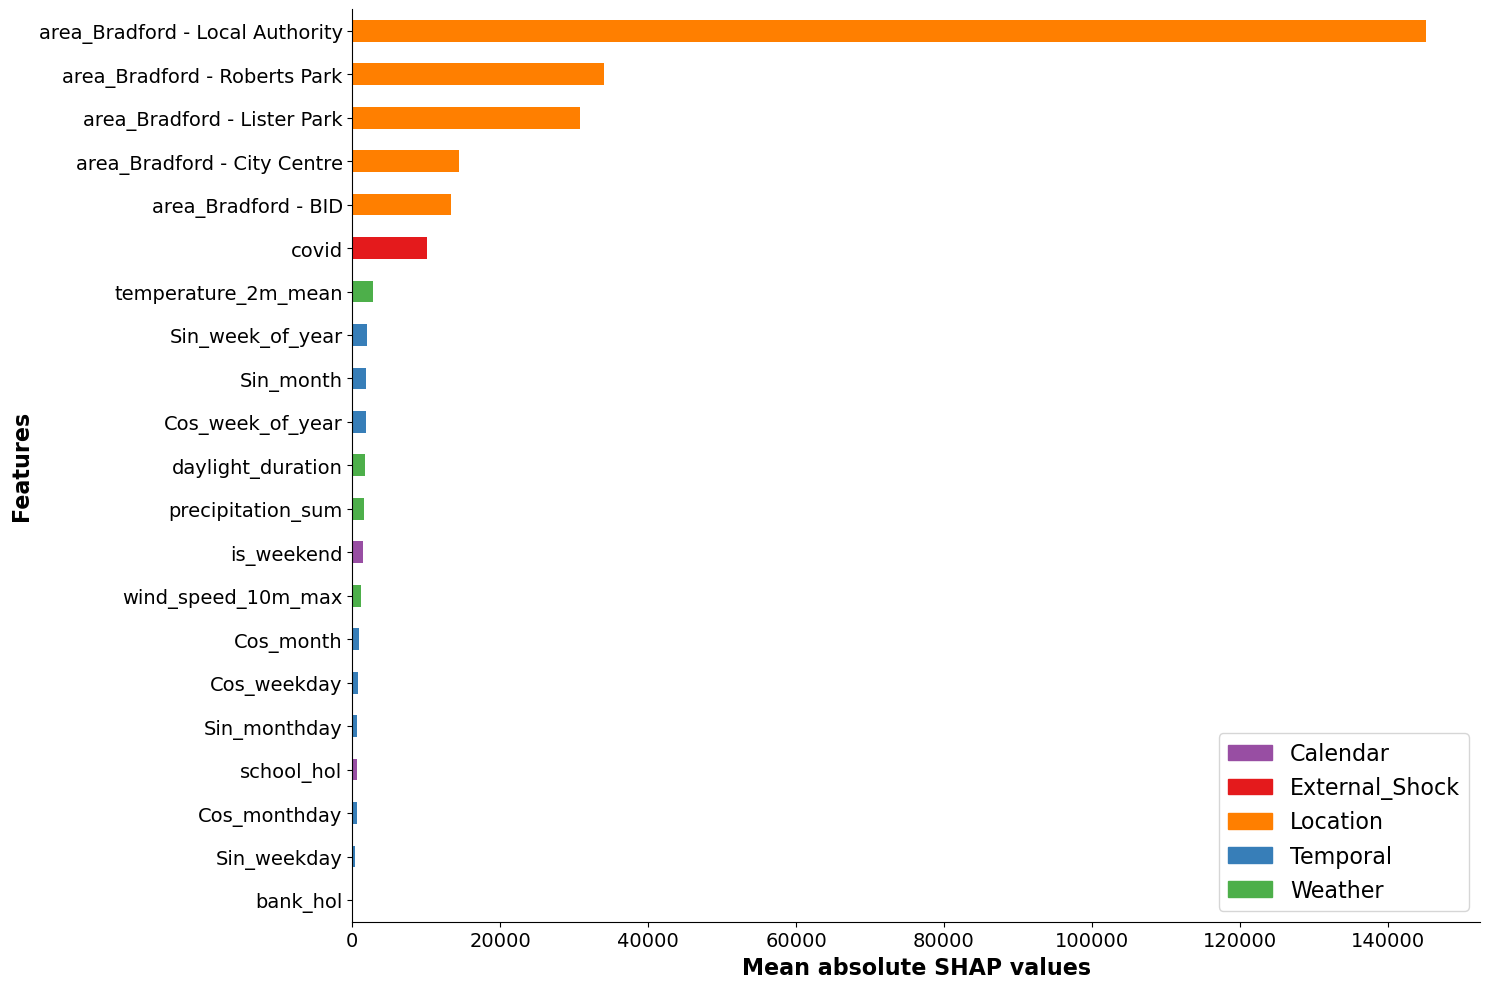

In [51]:
#Plot Mean Absolute SHAP values for each feature
import matplotlib.patches as mpatches

#Define feature groups
feature_groups = {
    'Sin_weekday': 'Temporal', 
    'Cos_weekday': 'Temporal', 
    'Sin_monthday': 'Temporal', 
    'Cos_monthday': 'Temporal',
    'Sin_week_of_year': 'Temporal', 
    'Cos_week_of_year': 'Temporal', 
    'Sin_month': 'Temporal', 
    'Cos_month': 'Temporal',
    'is_weekend': 'Calendar', 
    'bank_hol': 'Calendar', 
    'school_hol': 'Calendar', 
    'covid': 'External_Shock', 
    'temperature_2m_mean': 'Weather',
    'precipitation_sum': 'Weather', 
    'wind_speed_10m_max': 'Weather', 
    'daylight_duration': 'Weather', 
    'area_Bradford - BID': 'Location',
    'area_Bradford - City Centre': 'Location', 
    'area_Bradford - Lister Park': 'Location',
    'area_Bradford - Local Authority': 'Location',
    'area_Bradford - Roberts Park': 'Location'
}

#Define colors for each group
group_colors= {
    'Location': '#ff7f00',
    'Temporal': '#377eb8',
    'Weather': '#4daf4a',
    'Calendar': '#984ea3',
    'External_Shock': '#e41a1c',
}

#Get mean and sort values
mean_abs_shap = shap_df.abs().mean().sort_values()

#Get color list aligned with sorted features
colors = [
    group_colors[feature_groups[feature]]
    for feature in mean_abs_shap.index
]

#Plot
plt.figure(figsize=(15, 10))
mean_abs_shap.plot(kind='barh', color= colors)

plt.title('')
plt.xlabel('Mean absolute SHAP values', fontsize=16, weight='bold')
plt.ylabel('Features', fontsize=16, weight='bold')
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#Add legend
unique_groups = sorted(set(feature_groups.values()))
legend_handles = [
    mpatches.Patch(color=group_colors[group], label=group)
    for group in unique_groups
]

plt.legend(
    handles= legend_handles,
    title= '',
    fontsize= 16,
    loc= 'lower right'
)

plt.tight_layout()
plt.show()

In [52]:
#Get the absolute mean SHAP values
mean_abs_shap

bank_hol                               56.930143
Sin_weekday                           339.624660
Cos_monthday                          618.146473
school_hol                            646.913362
Sin_monthday                          678.314462
Cos_weekday                           706.825975
Cos_month                             958.289354
wind_speed_10m_max                   1170.777384
is_weekend                           1413.217367
precipitation_sum                    1551.375856
daylight_duration                    1701.304892
Cos_week_of_year                     1875.173357
Sin_month                            1883.165317
Sin_week_of_year                     2025.097496
temperature_2m_mean                  2780.934229
covid                               10060.033620
area_Bradford - BID                 13358.986161
area_Bradford - City Centre         14374.048176
area_Bradford - Lister Park         30749.501149
area_Bradford - Roberts Park        33995.542204
area_Bradford - Loca

# 7- Using RFR model to evaluate 2025 events

Now that the final Random Forest Regression has been trained on the footfall data between 2019 and 2024, the model is used to predict what footfall would have looked like in 2025 without any cultural events, thus without the Bradford 2025 City of Culture programme. Comparing the predicted vs the actual footfall values allows to evaluate the impact of the programme by using footfall as a proxy.

In [53]:
#Load historical footfall (2019-2024) data again
data = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\ML Analysis - Polygons with district\footfall_cleaned_19_24.csv")
#Drop columns that are not variables used in the analysis
data.drop(['Unnamed: 0', 'month', 'weekday', 'week_of_year', 'year'], axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10862 entries, 0 to 10861
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   datestamp                        10862 non-null  object 
 1   estimated_actual_footfall        10862 non-null  float64
 2   Sin_weekday                      10862 non-null  float64
 3   Cos_weekday                      10862 non-null  float64
 4   Sin_monthday                     10862 non-null  float64
 5   Cos_monthday                     10862 non-null  float64
 6   Sin_week_of_year                 10862 non-null  float64
 7   Cos_week_of_year                 10862 non-null  float64
 8   Sin_month                        10862 non-null  float64
 9   Cos_month                        10862 non-null  float64
 10  is_weekend                       10862 non-null  int64  
 11  bank_hol                         10862 non-null  int64  
 12  school_hol        

In [54]:
#Get data to make prediction on -> the 2025 footfall data
data_2025 = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\ML Analysis - Polygons with district\footfall_cleaned_2025.csv")
#For time series analysis, the data needs to be in chronological order
# thus there is a need to reset the indexes based on datestamp
data_2025 = data_2025.sort_values('datestamp')
data_2025 = data_2025.reset_index(drop=True)
#Check
data_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1533 entries, 0 to 1532
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       1533 non-null   int64  
 1   datestamp                        1533 non-null   object 
 2   estimated_actual_footfall        1533 non-null   float64
 3   year                             1533 non-null   int64  
 4   month                            1533 non-null   int64  
 5   weekday                          1533 non-null   int64  
 6   week_of_year                     1533 non-null   int64  
 7   Sin_weekday                      1533 non-null   float64
 8   Cos_weekday                      1533 non-null   float64
 9   Sin_monthday                     1533 non-null   float64
 10  Cos_monthday                     1533 non-null   float64
 11  Sin_week_of_year                 1533 non-null   float64
 12  Cos_week_of_year    

In [55]:
data_2025.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,year,month,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_monthday,...,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration,area_name,area_Bradford - BID,area_Bradford - City Centre,area_Bradford - Lister Park,area_Bradford - Local Authority,area_Bradford - Roberts Park
0,23570,2025-01-01,93047.155,2025,1,2,1,0.866025,-0.5,0.201299,...,5.187500,30.100000,26.587042,27122.145,Bradford - BID,1,0,0,0,0
1,23571,2025-01-01,58830.400,2025,1,2,1,0.866025,-0.5,0.201299,...,5.187500,30.100000,26.587042,27122.145,Bradford - City Centre,0,1,0,0,0
2,23572,2025-01-01,35005.450,2025,1,2,1,0.866025,-0.5,0.201299,...,5.187500,30.100000,26.587042,27122.145,Bradford - Lister Park,0,0,1,0,0
3,23573,2025-01-01,577601.000,2025,1,2,1,0.866025,-0.5,0.201299,...,4.930749,29.900003,30.606880,27122.145,Bradford - Local Authority,0,0,0,1,0
4,23574,2025-01-01,6041.470,2025,1,2,1,0.866025,-0.5,0.201299,...,5.187500,30.100000,26.587042,27122.145,Bradford - Roberts Park,0,0,0,0,1


In [56]:
#Drop columns that are not variables used in the analysis
data_2025.drop(['Unnamed: 0', 'month', 'weekday', 'week_of_year', 'year'], axis=1, inplace=True)

#Double check - Drop rows with no estimated_actual_footfall (won't allow comparison with predicted values)
data_2025 = data_2025.dropna(subset=['estimated_actual_footfall'])
data_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1533 entries, 0 to 1532
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   datestamp                        1533 non-null   object 
 1   estimated_actual_footfall        1533 non-null   float64
 2   Sin_weekday                      1533 non-null   float64
 3   Cos_weekday                      1533 non-null   float64
 4   Sin_monthday                     1533 non-null   float64
 5   Cos_monthday                     1533 non-null   float64
 6   Sin_week_of_year                 1533 non-null   float64
 7   Cos_week_of_year                 1533 non-null   float64
 8   Sin_month                        1533 non-null   float64
 9   Cos_month                        1533 non-null   float64
 10  is_weekend                       1533 non-null   int64  
 11  bank_hol                         1533 non-null   int64  
 12  school_hol          

In [57]:
#Prepare data for modelling
Xfull = data_2025.drop(['estimated_actual_footfall'], axis =1) #Predictor variables
Yfull = data_2025['estimated_actual_footfall'].values #target variable

In [58]:
#Forecasting function

"""
Forecasting for future footfall

model: is the previously trained Random Forest Regressor model
future_df: is the data we want to predict the footfall for
feature_cols: list of features used to train the model (excludes datestamp)

"""

def get_forecast(model, future_df, feature_cols):

    #Get predictors feature cols from 2025 data
    X_future = future_df[feature_cols]

    future_df = future_df.copy()
    #Run model to make predictions
    future_df['predicted_footfall'] = model.predict(X_future)
    
    return future_df[['datestamp', 'area_name', 'predicted_footfall', 'estimated_actual_footfall']]

In [59]:
#Define the list of features used in model training
features = ['Sin_weekday', 
            'Cos_weekday', 
            'Sin_monthday', 
            'Cos_monthday',
            'Sin_week_of_year', 
            'Cos_week_of_year', 
            'Sin_month', 
            'Cos_month',
            'is_weekend', 
            'bank_hol', 
            'school_hol', 
            'covid', 
            'temperature_2m_mean',
            'precipitation_sum', 
            'wind_speed_10m_max', 
            'daylight_duration', 
            'area_Bradford - BID',
            'area_Bradford - City Centre', 
            'area_Bradford - Lister Park',
            'area_Bradford - Local Authority',
            'area_Bradford - Roberts Park'
            ]

In [60]:
#Ensure the datestamp columns of both datasets are datetime
data_2025['datestamp'] = pd.to_datetime(data_2025['datestamp'])
data['datestamp'] = pd.to_datetime(data['datestamp'])

The forecasting function with the Random Forest Regression model is called to create footfall predictions for 2025:

In [61]:
#Call the recursive forecasting function
predictions_2025 = get_forecast(rf_model_final,
                                data_2025,
                                features)

predictions_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1533 entries, 0 to 1532
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   datestamp                  1533 non-null   datetime64[ns]
 1   area_name                  1533 non-null   object        
 2   predicted_footfall         1533 non-null   float64       
 3   estimated_actual_footfall  1533 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 48.0+ KB


c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [62]:
predictions_2025.head(20)

,datestamp,area_name,predicted_footfall,estimated_actual_footfall
0,2025-01-01,Bradford - BID,108748.692139,93047.155
1,2025-01-01,Bradford - City Centre,91291.491076,58830.400
2,2025-01-01,Bradford - Lister Park,41968.547529,35005.450
3,2025-01-01,Bradford - Local Authority,645513.819846,577601.000
4,2025-01-01,Bradford - Roberts Park,22865.273732,6041.470
5,2025-01-02,Bradford - BID,90021.937189,107165.890
6,2025-01-02,Bradford - City Centre,76069.257072,60005.720
7,2025-01-02,Bradford - Lister Park,29318.820960,42658.160
8,2025-01-02,Bradford - Local Authority,645600.705963,607459.000
9,2025-01-02,Bradford - Roberts Park,12287.317064,8499.360


Visualize prediction vs actual footfall values in 2025, for each of the locations. To do so calculate the percentage change between the prediction and actual footfall for each day.

In [63]:
#Calculate the daily percentage change between predictions and actual values
predictions_2025['Percentage_Increase'] = ((predictions_2025['estimated_actual_footfall'] - predictions_2025['predicted_footfall']) / abs(predictions_2025['predicted_footfall'])) * 100

Also calculate the overall annual percentage change between the predictions and actual footfall in 2025. To do so, only include the dates I have data for in 2025 (some locations have a few missing days in 2025).

In [64]:
#Calculate the annual percentage change between footfall prediction and actual values for each location
pct_change_by_region = {}

#Isolate areas
areas = predictions_2025['area_name'].unique()

for area in areas:
    df_area = predictions_2025[predictions_2025['area_name'] == area]
    
    total_pred = df_area['predicted_footfall'].sum()
    total_actual = df_area['estimated_actual_footfall'].sum()

    pct_change = (total_actual - total_pred)/ total_pred * 100
    pct_change_by_region[area] = pct_change

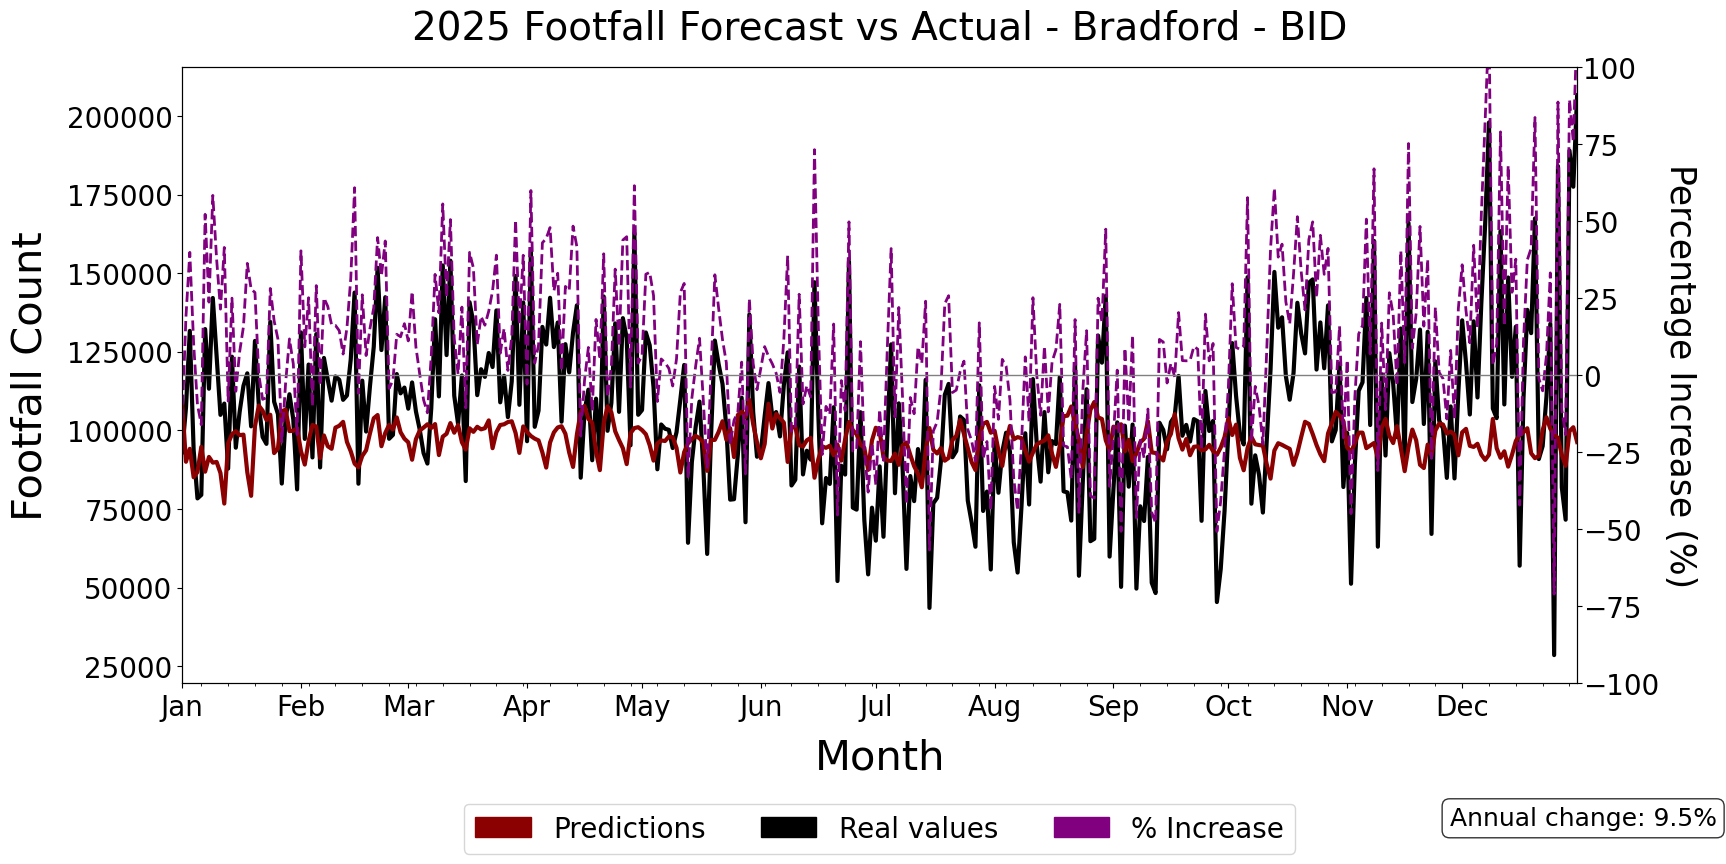


Summary stats for Bradford - BID


count    365.000000
mean       9.737454
std       27.970640
min      -71.107540
25%       -7.874960
50%        8.742982
75%       25.831370
max      114.554392
Name: Percentage_Increase, dtype: float64

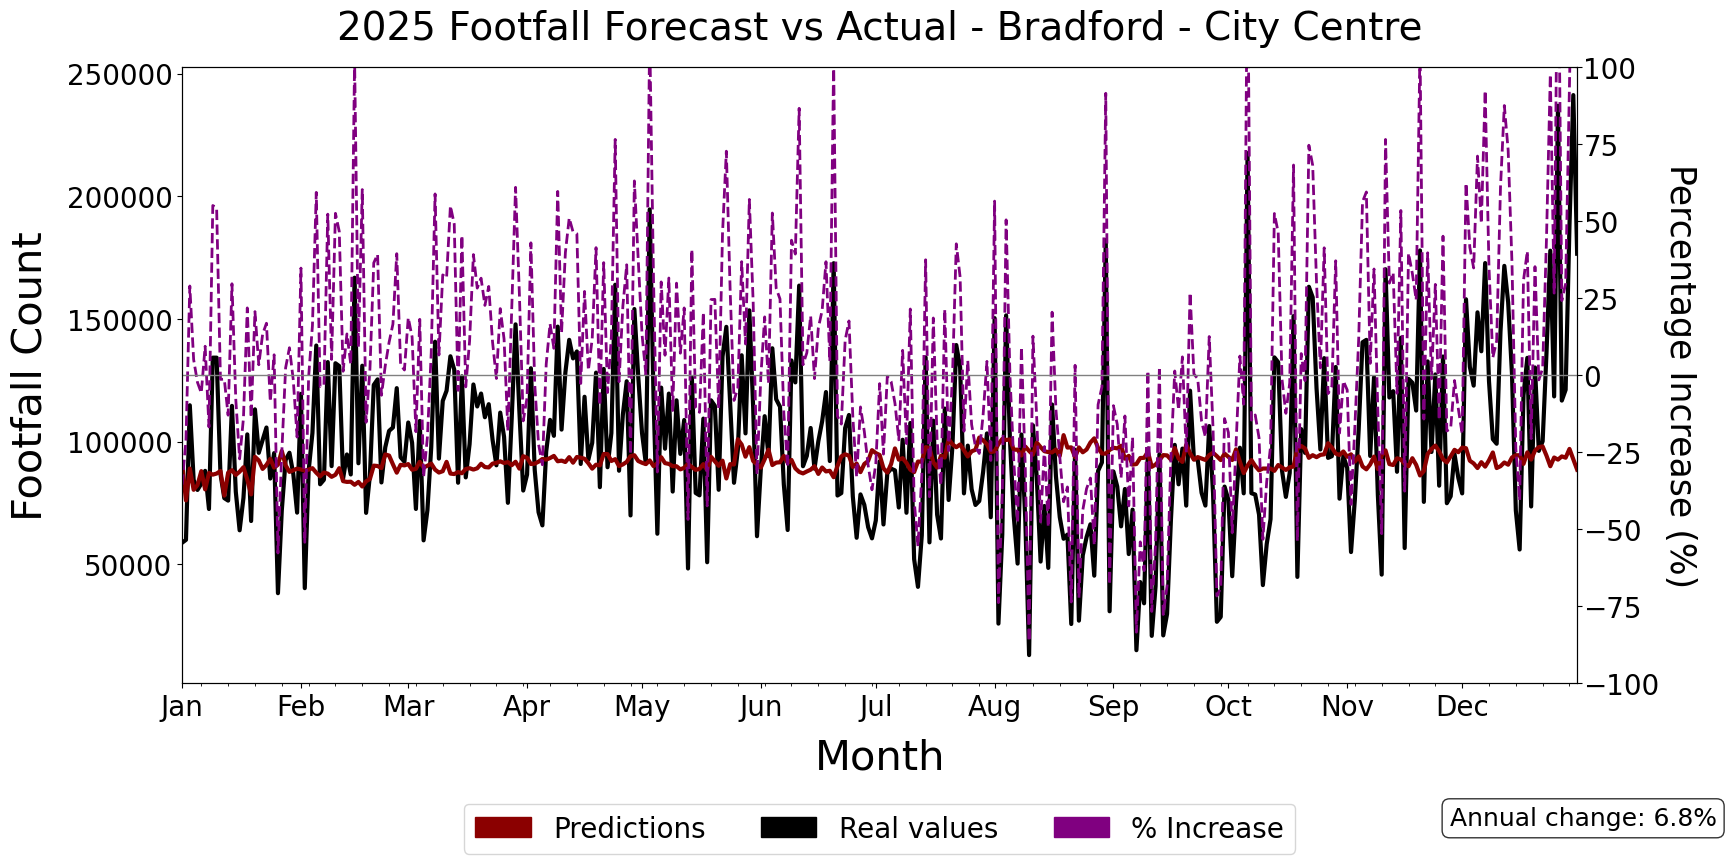


Summary stats for Bradford - City Centre


count    365.000000
mean       7.160141
std       38.427177
min      -86.446269
25%      -16.849797
50%        3.040601
75%       30.688671
max      159.832091
Name: Percentage_Increase, dtype: float64

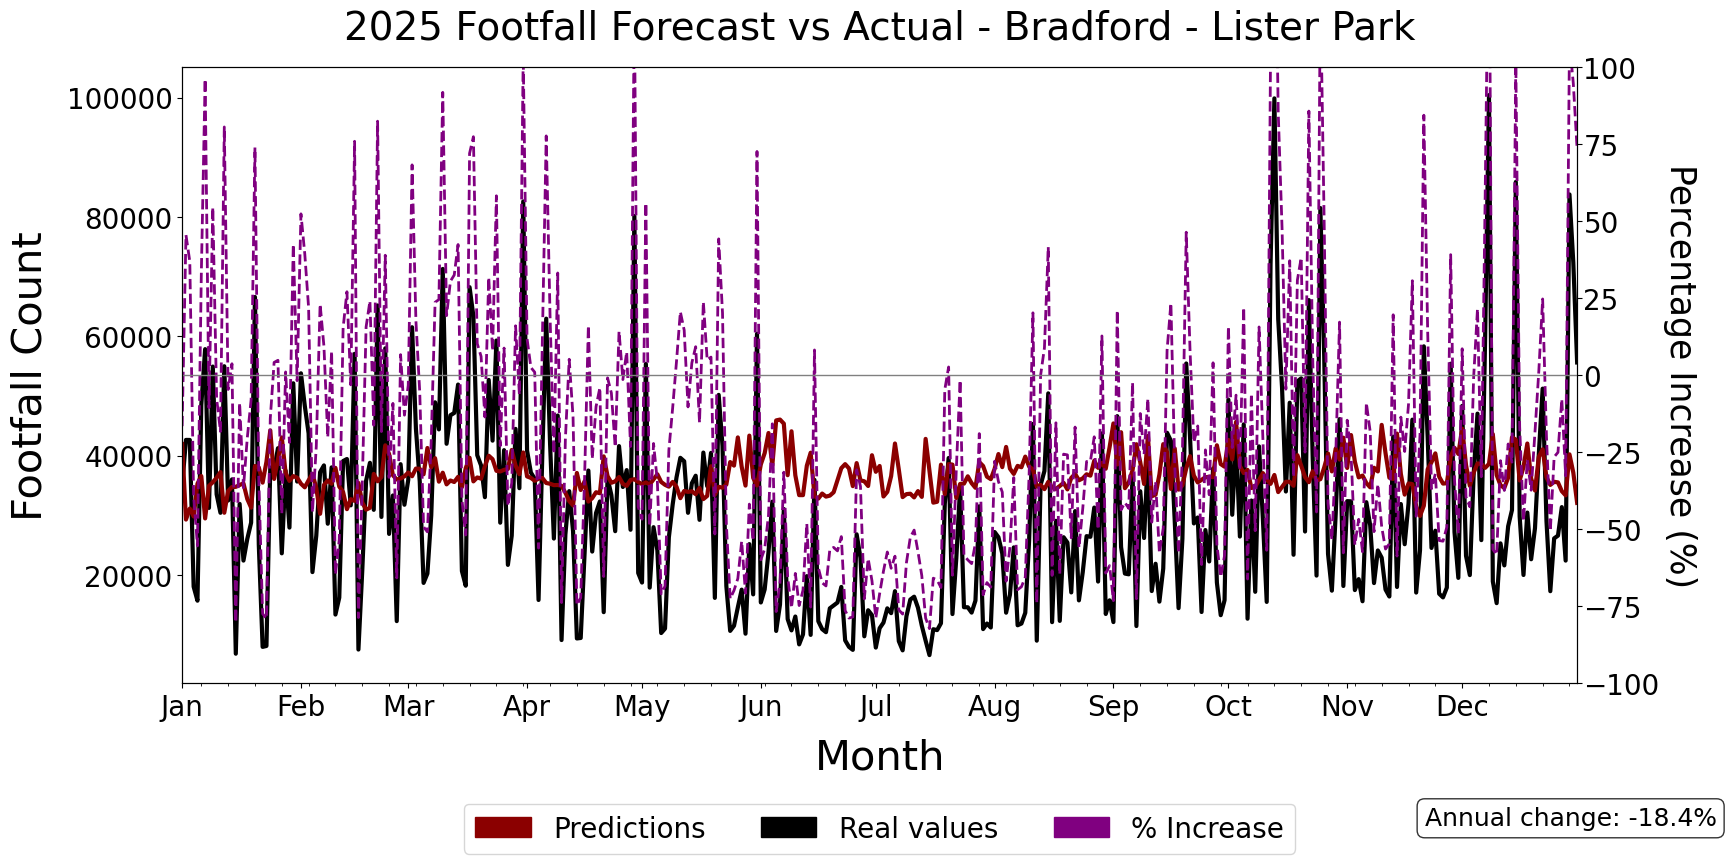


Summary stats for Bradford - Lister Park


count    365.000000
mean     -17.872430
std       45.599838
min      -82.311976
25%      -54.774632
50%      -25.080216
75%        7.745299
max      171.449000
Name: Percentage_Increase, dtype: float64

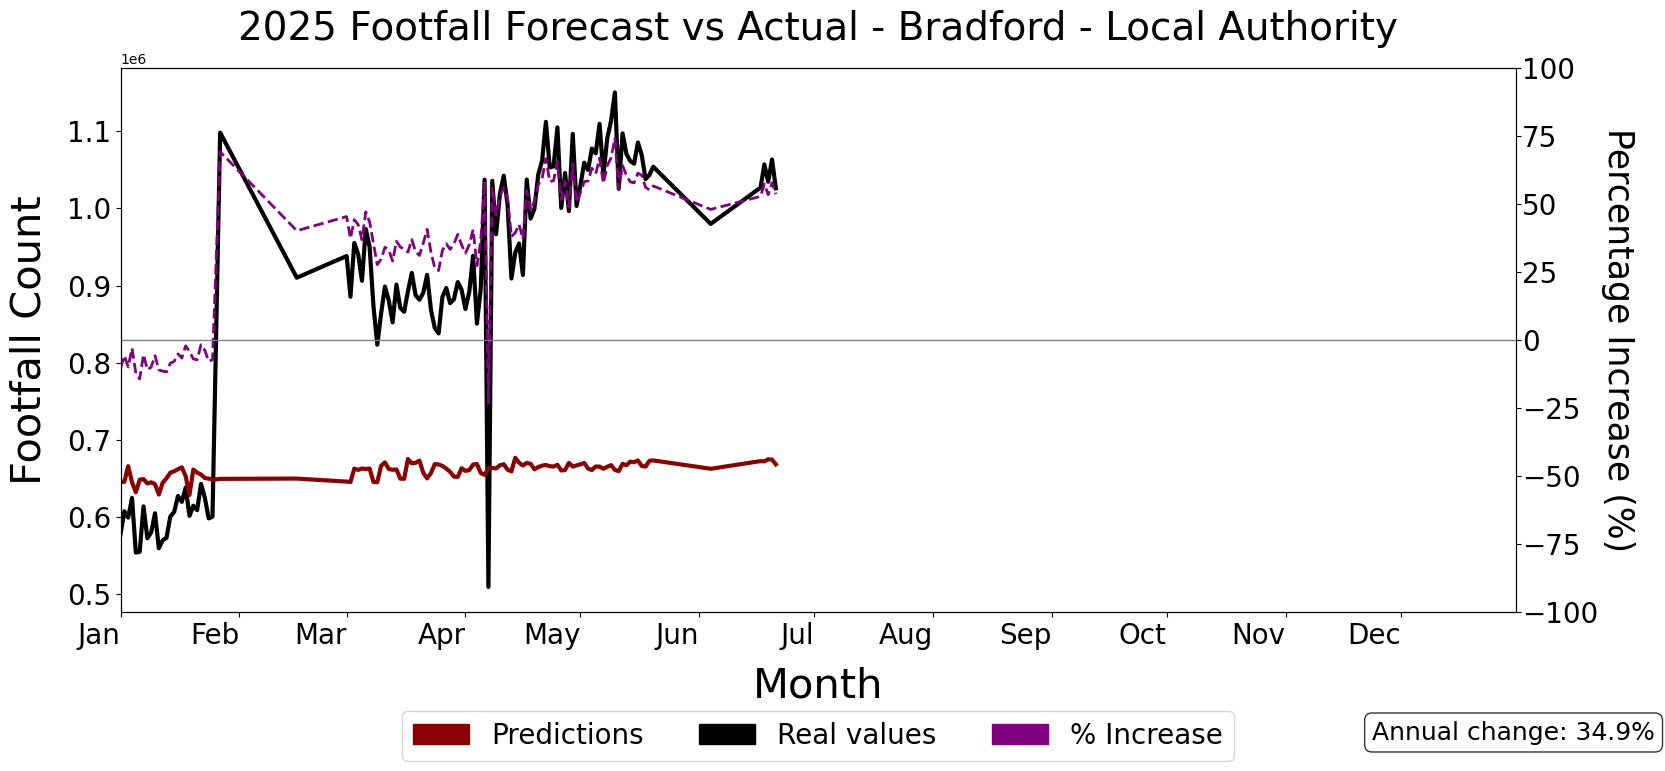


Summary stats for Bradford - Local Authority


count    114.000000
mean      34.680707
std       25.988449
min      -23.228691
25%       27.313834
50%       39.013591
75%       56.061671
max       74.008034
Name: Percentage_Increase, dtype: float64

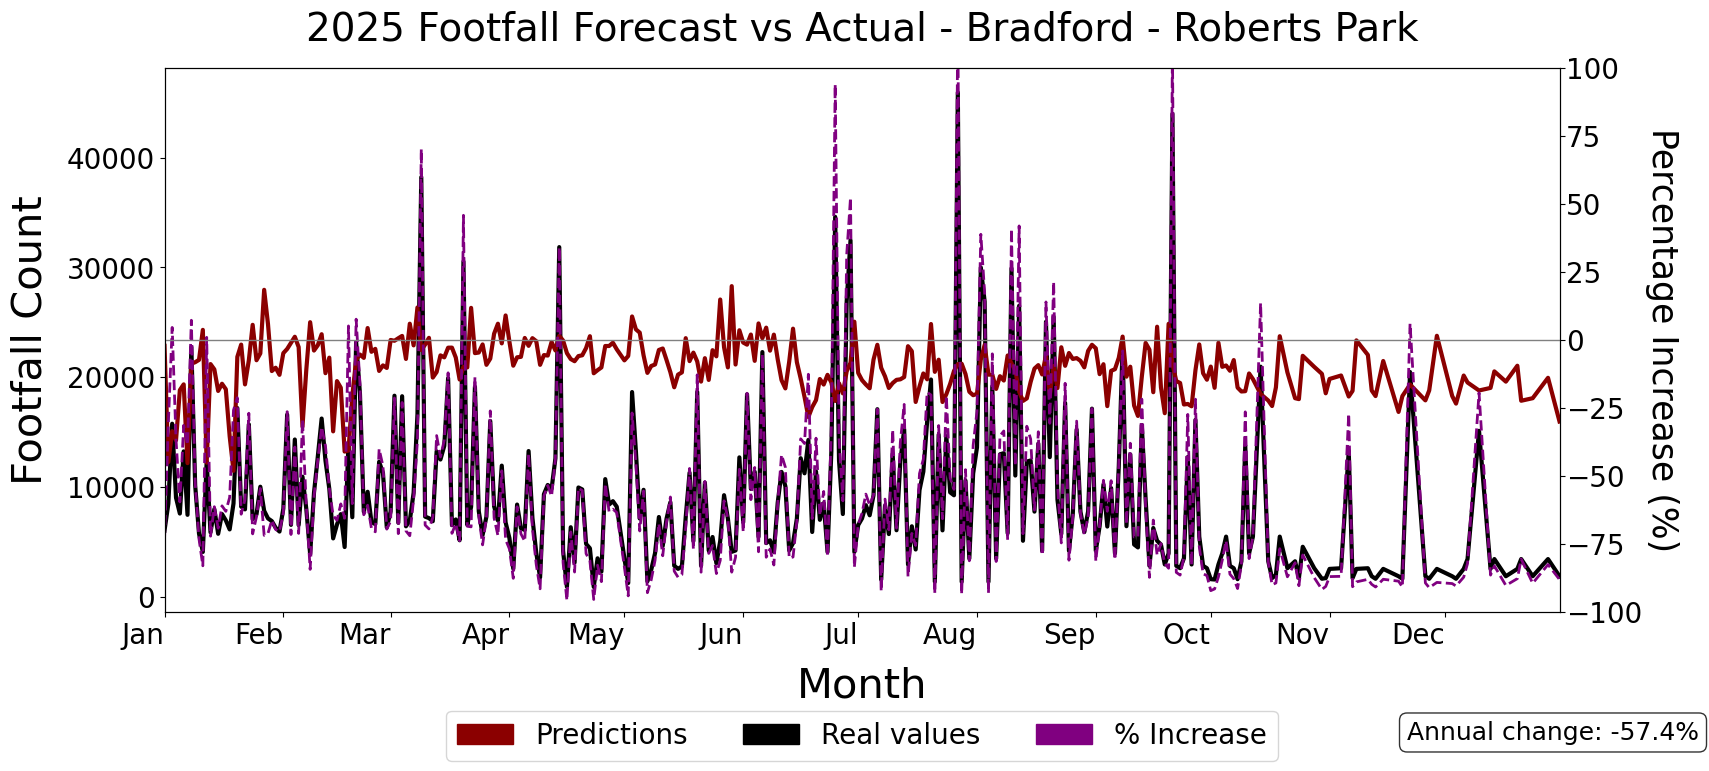


Summary stats for Bradford - Roberts Park


count    324.000000
mean     -57.121294
std       33.795721
min      -95.875406
25%      -81.110889
50%      -66.355496
75%      -41.454968
max      116.689307
Name: Percentage_Increase, dtype: float64

In [65]:
#Plot actual footfall, predicted footfall, and percentage increase between the two for comparison
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.pyplot as plt


#Ensure datestamp is datetime
predictions_2025['datestamp'] = pd.to_datetime(predictions_2025['datestamp'])

include_percent_increase = True
areas = predictions_2025['area_name'].unique()

#Loop through areas to create plot for each
for area in areas:
    df_r = predictions_2025[predictions_2025['area_name'] == area].copy()

    fig, ax = plt.subplots(figsize = (18,8))

    #Plot actual and predicted footfall
    df_r.plot(x='datestamp', y='estimated_actual_footfall', ax=ax, color='black', linewidth=3, legend =False)
    df_r.plot(x='datestamp', y='predicted_footfall', ax=ax, color='darkred', linewidth=3, legend =False)

    #Plot percentage increase on secondary axis
    if include_percent_increase==True:
        ax2 = ax.twinx()
        df_r.plot(x='datestamp', y='Percentage_Increase', ax=ax2, color='purple', linewidth=2, legend =False, linestyle = 'dashed')
        ax2.set_ylabel('Percentage Increase (%)', fontsize=25, rotation=270, labelpad=27)
        ax2.tick_params(axis='both', which='major', labelsize=20, pad=1)
        ax2.set_ylim(-100,100)

    #Set x axis to show month names, and tick parameters
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    #Force x axis to start in Jan and end in December
    ax.set_xlim([pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31')])
    ax.tick_params(axis='x', labelsize=20, rotation=0)
    ax.tick_params(axis='y', labelsize=20)

    #Set labels of axes
    ax.set_xlabel('Month', fontsize = 30, labelpad=12)
    ax.set_ylabel ('Footfall Count',fontsize=30, labelpad=12)

    #Title
    ax.set_title(f'2025 Footfall Forecast vs Actual - {area}', fontsize=28, pad=20)
    #Legend
    colors_leg = ['darkred', 'black', 'purple']
    texts = ['Predictions', 'Real values','% Increase'] 
    patches = [ mpatches.Patch(color=colors_leg[i], label="{:s}".format(texts[i]) ) for i in range(len(texts)) ]    
    
    #Create annotations with pct_change
    pct = pct_change_by_region[area]
    
    ax.text(
        1.1,
        -0.2,
        f'Annual change: {pct:.1f}%',
        transform= ax.transAxes,
        ha= 'right',
        va= 'top',
        fontsize=18,
        bbox= dict(boxstyle='round', facecolor='white', alpha=0.8))


    plt.axhline(y = 0, color = 'grey', linestyle = '-', linewidth=1)     
    plt.legend(handles=patches, bbox_to_anchor=(0.5 , -0.3), loc='lower center', ncol=3, prop={'size': 20});

    plt.show()
    
    #Print stats
    print(f'\nSummary stats for {area}')
    display(df_r['Percentage_Increase'].describe())

Look at annual percentage change between model prediction and observed footfall VS naive year-on-year comparison:

Bradford - BID
* 2024 vs 2025 = 9.8% change
* 2025 pred vs actual = 9.5% change

Bradford - City Centre
* 2024 vs 2025 = 12.4% change
* 2025 pred vs actual = 6.8% change

Bradford - Lister Park
* 2024 vs 2025 = -2.5% change
* 2025 pred vs actual = -18.4% change

Bradford - Roberts Park
* 2024 vs 2025 = 10.9% change
* 2025 pred vs actual = -57.4% change

Bradford - Local Authority
* 2024 vs 2025 = 42.3% change
* 2025 pred vs actual = 34.9% change

Look at monthly percentage chnage between prediction and observed footfall:

In [66]:
areas = predictions_2025['area_name'].unique()

#Loop through areas to get stats
for area in areas:
    df_r = predictions_2025[predictions_2025['area_name'] == area].copy()

    #Get the monthly %increase averages to see which month were most affected by the Bradford25 events
    monthly_2025 = df_r.groupby(predictions_2025['datestamp'].dt.month)['Percentage_Increase'].mean()
    print(f'\nMonthly Percent Increase stats for {area}')
    print(monthly_2025)


Monthly Percent Increase stats for Bradford - BID
datestamp
1     13.008950
2     18.532720
3     19.030136
4     21.396048
5      3.634306
6     -1.211917
7     -7.796999
8     -6.627842
9     -9.685916
10    20.804767
11    12.356902
12    33.740267
Name: Percentage_Increase, dtype: float64

Monthly Percent Increase stats for Bradford - City Centre
datestamp
1      0.075109
2     18.742589
3     17.235876
4     19.560039
5     14.689957
6     10.494305
7     -9.543285
8    -22.831048
9    -27.822262
10     6.826064
11    14.250508
12    44.972530
Name: Percentage_Increase, dtype: float64

Monthly Percent Increase stats for Bradford - Lister Park
datestamp
1     -3.363164
2     -1.407159
3     12.884635
4     -8.424500
5    -19.399944
6    -57.973052
7    -56.630531
8    -35.552930
9    -28.559117
10     9.805496
11   -25.637528
12    -0.201965
Name: Percentage_Increase, dtype: float64

Monthly Percent Increase stats for Bradford - Local Authority
datestamp
1    -4.808213
2    40.059